In [2]:
import pandas as p
import seaborn as sb
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

In [3]:
df_m = p.read_csv("share-of-women-who-are-smoking.csv")
df_m = df_m.sort_values(ascending=False, by="Share of female adults who smoke or use tobacco (age-standardized)")
df_m = df_m.rename(columns={"Share of female adults who smoke or use tobacco (age-standardized)": "Porcentaje de mujeres que fuman"})
df_h = p.read_csv("share-of-men-who-are-smoking.csv")
df_h = df_h.sort_values(ascending=False, by="Share of male adults who smoke or use tobacco (age-standardized)")
df_h = df_h.rename(columns={"Share of male adults who smoke or use tobacco (age-standardized)": "Distribución de hombres que fuman (%)"})

Deberíamos eliminar Corea del norte

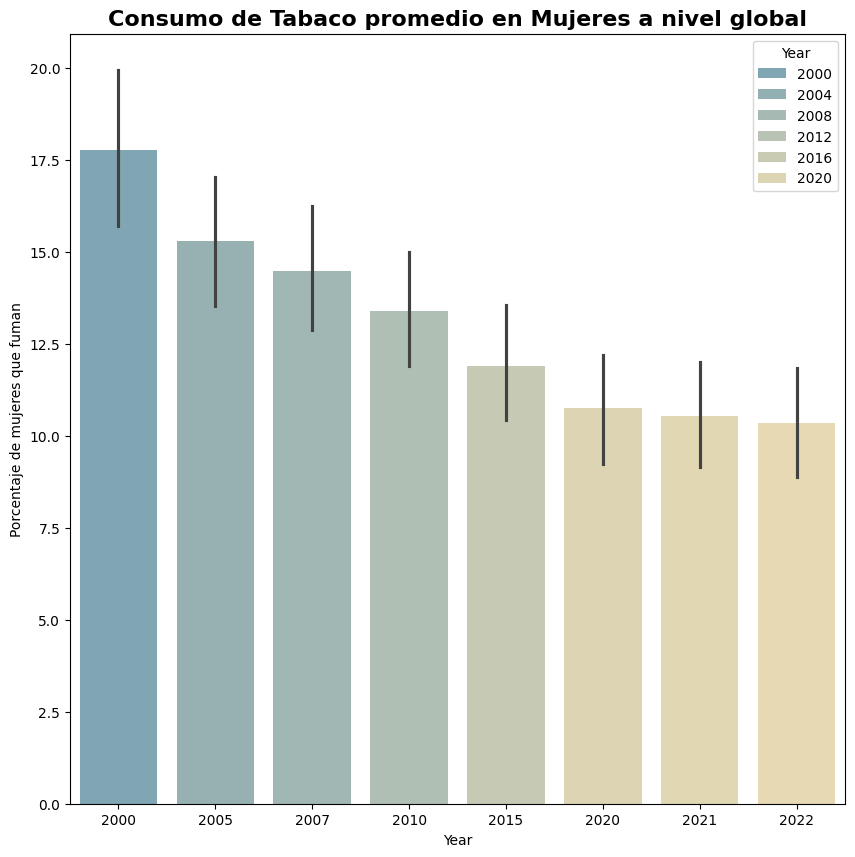

In [4]:
plt.figure(figsize=(10, 10))
sb.barplot(data=df_m, x="Year", y="Porcentaje de mujeres que fuman", hue="Year", palette="blend:#7AB,#EDA")
plt.title("Consumo de Tabaco promedio en Mujeres a nivel global", fontsize=16, fontweight='bold')
plt.show()

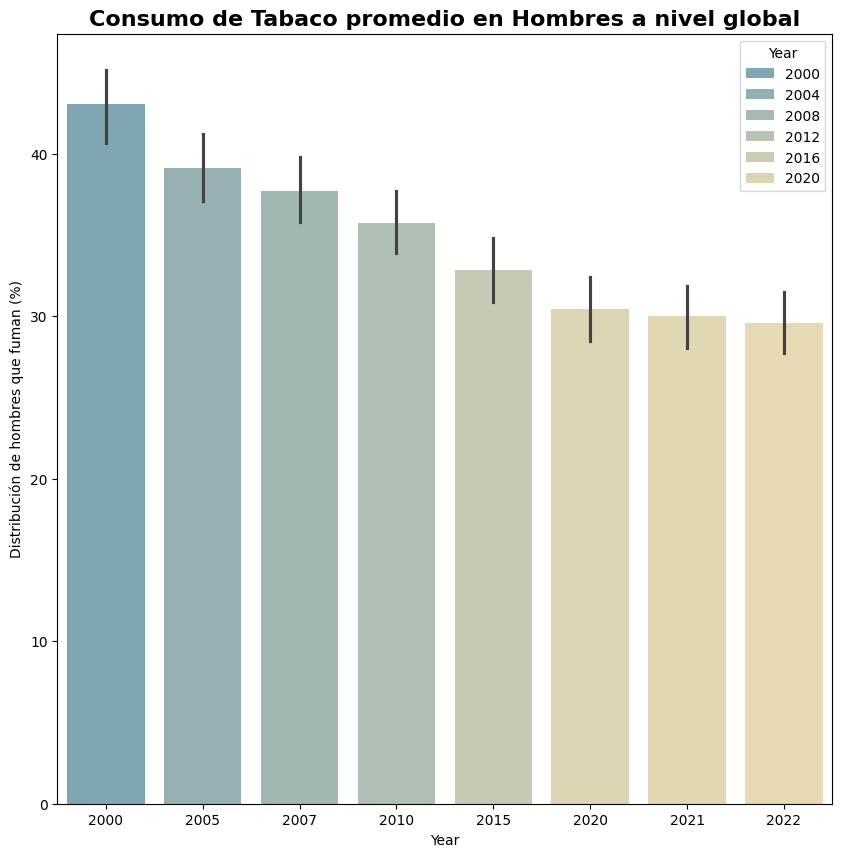

In [5]:
plt.figure(figsize=(10, 10))
sb.barplot(data=df_h, x="Year", y="Distribución de hombres que fuman (%)", hue="Year", palette="blend:#7AB,#EDA")
plt.title("Consumo de Tabaco promedio en Hombres a nivel global", fontsize=16, fontweight='bold')
plt.show()

In [6]:
df_prom_m = df_m.groupby("Entity")["Porcentaje de mujeres que fuman"].mean().reset_index()
df_prom_m = df_prom_m.sort_values("Porcentaje de mujeres que fuman", ascending=False).reset_index(drop=True)
df_prom_m

,Entity,Porcentaje de mujeres que fuman
0,Nauru,56.7875
1,Serbia,39.0750
2,Kiribati,37.2375
3,Bulgaria,37.1750
4,Greece,35.9875
...,...,...
171,Egypt,0.5750
172,Turkmenistan,0.5625
173,Oman,0.4875
174,Azerbaijan,0.1875


In [7]:
df_prom_h = df_h.groupby("Entity")["Distribución de hombres que fuman (%)"].mean().reset_index()
df_prom_h = df_prom_h.sort_values("Distribución de hombres que fuman (%)", ascending=False).reset_index(drop=True)
df_prom_h

,Entity,Distribución de hombres que fuman (%)
0,Myanmar,74.9750
1,East Timor,74.8750
2,Indonesia,68.5125
3,Kiribati,64.8375
4,Papua New Guinea,61.1750
...,...,...
171,Barbados,13.4250
172,Sao Tome and Principe,12.2875
173,Nigeria,10.7750
174,Ethiopia,9.8000


In [8]:
df_prom_h[df_prom_h["Entity"] == "Chile"]

,Entity,Distribución de hombres que fuman (%)
64,Chile,39.05


In [9]:
df_hombres_2022 = df_h[df_h["Year"] == 2022]
df_mujeres_2022 = df_m[df_m["Year"] == 2022]
df_final = p.merge(df_hombres_2022, df_mujeres_2022, on=["Entity", "Code", "Year"])

idx_max = df_final["Distribución de hombres que fuman (%)"].idxmax()
pais_max = df_final.loc[idx_max, "Entity"]
val_max = round(df_final.loc[idx_max, "Distribución de hombres que fuman (%)"], 1)

idx_min = df_final["Distribución de hombres que fuman (%)"].idxmin()
pais_min = df_final.loc[idx_min, "Entity"]
val_min = round(df_final.loc[idx_min, "Distribución de hombres que fuman (%)"], 1)

texto_curiosidades_h = f"<b>Curiosidades (Hombres 2022):</b><br>Mayor %: {pais_max} ({val_max}%)<br>Menor %: {pais_min} ({val_min}%)"
texto_fuentes_h = "https://ourworldindata.org/grapher/share-of-men-who-are-smoking"

fig = px.choropleth(df_final, locations="Code", color="Distribución de hombres que fuman (%)", hover_name="Entity", color_continuous_scale="Reds", title="Porcentaje de Hombres Fumadores por País (2022)")
fig.update_geos(showcoastlines=True, coastlinecolor="Black", showland=True, landcolor="lightgrey", projection_type="natural earth")

#Acá las curiosidades
fig.add_annotation(text=texto_curiosidades_h, x=0.02, y=0.1, xref="paper", yref="paper", showarrow=False, align="left", bgcolor="rgba(255, 255, 255, 0.8)", bordercolor="black", borderwidth=1, font=dict(size=12))

# Acá las referencias
fig.add_annotation(text=texto_fuentes_h, x=0.5, y=-0.15, xref="paper", yref="paper", showarrow=False, align="center", font=dict(size=10, color="gray"))

#Lineas simplemente de margen
fig.update_layout(margin=dict(l=0, r=0, t=50, b=80))
fig.write_html("Mapa_geografico_hombres_fumadores_2022.html")

idx_max_m = df_final["Porcentaje de mujeres que fuman"].idxmax()
pais_max_m = df_final.loc[idx_max_m, "Entity"]
val_max_m = round(df_final.loc[idx_max_m, "Porcentaje de mujeres que fuman"], 1)

idx_min_m = df_final["Porcentaje de mujeres que fuman"].idxmin()
pais_min_m = df_final.loc[idx_min_m, "Entity"]
val_min_m = round(df_final.loc[idx_min_m, "Porcentaje de mujeres que fuman"], 1)

texto_curiosidades_m = f"<b>Datos Relevantes (Mujeres 2022):</b><br>Mayor %: {pais_max_m} ({val_max_m}%)<br>Menor %: {pais_min_m} ({val_min_m}%)"
texto_fuentes_m = "https://ourworldindata.org/grapher/share-of-women-who-are-smoking"

fig = px.choropleth(df_final,locations="Code", color="Porcentaje de mujeres que fuman", hover_name="Entity", color_continuous_scale="YlOrRd", title="Porcentaje de Mujeres Fumadoras por País (2022)")
fig.update_geos(showcoastlines=True, coastlinecolor="Black", showland=True, landcolor="lightgrey", projection_type="natural earth")

#Acá las curiosidades
fig.add_annotation(text=texto_curiosidades_m, x=0.02, y=0.04, xref="paper", yref="paper", showarrow=False, align="left", bgcolor="rgba(255, 255, 255, 0.8)", bordercolor="black", borderwidth=1, font=dict(size=12))

# Acá las referencias
fig.add_annotation(text=texto_fuentes_m, x=0.5, y=0, xref="paper", yref="paper", showarrow=False, align="center", font=dict(size=10, color="gray"))

#Coloco la leyenda para los sin datos y posteriormente pongo margen
fig.add_trace(go.Scattergeo(lon=[0], lat=[999], marker=dict(size=15, color="lightgrey", symbol="square", line=dict(width=1, color="black")), name="Sin datos", mode="markers", showlegend=True))

fig.update_layout(legend=dict(title="", yanchor="bottom", y=0.08, xanchor="right", x=0.98, bgcolor="rgba(255, 255, 255, 0.8)", bordercolor="black", borderwidth=1), width=1100, height=700)

In [10]:
fig.write_html("Mapa_geografico_mujeres_fumadores_2022.html")

In [11]:
df_m

,Entity,Code,Year,Porcentaje de mujeres que fuman
896,Nauru,NRU,2000,70.0
897,Nauru,NRU,2005,63.9
898,Nauru,NRU,2007,61.6
899,Nauru,NRU,2010,58.4
288,Comoros,COM,2000,56.6
...,...,...,...,...
954,North Korea,PRK,2007,0.0
956,North Korea,PRK,2015,0.0
957,North Korea,PRK,2020,0.0
958,North Korea,PRK,2021,0.0


In [12]:
df_m["Year"].unique()

array([2000, 2005, 2007, 2010, 2015, 2020, 2021, 2022])

In [19]:
import json
import pandas as pd

# 1. Preparación del DataFrame "Ambos" (Promedio)
df_all = pd.merge(
    df_m[["Entity", "Code", "Year", "Porcentaje de mujeres que fuman"]],
    df_h[["Entity", "Code", "Year", "Distribución de hombres que fuman (%)"]],
    on=["Entity", "Code", "Year"]
)
df_all["Promedio"] = (df_all["Porcentaje de mujeres que fuman"] + df_all["Distribución de hombres que fuman (%)"]) / 2

# VARIABLES MODIFICABLES
PALETA_MAPA = "Viridis" 
TITULO_PROYECTO = "Análisis Global de Tabaquismo"
LINK_TEXTO = "Datos obtenidos de Our World in Data / WHO"
LINK_URL = "https://ourworldindata.org/smoking"

# EXPORTACIÓN
json_m = df_m.to_json(orient="records")
json_h = df_h.to_json(orient="records")
json_a = df_all.to_json(orient="records")
anios_lista = sorted(df_m["Year"].unique().tolist())

# HTML Reducido: Solo Estructura, CSS y carga de Datos
html_final = f"""
<!DOCTYPE html>
<html lang="es">
<head>
    <meta charset="UTF-8">
    <title>{TITULO_PROYECTO}</title>
    <script src="https://cdn.plot.ly/plotly-2.32.0.min.js"></script>
    <script src="https://cdnjs.cloudflare.com/ajax/libs/tone/14.8.49/Tone.js"></script>
    <style>
        body {{ background: #0e1117; color: #e6edf3; font-family: "Source Sans 3", sans-serif; margin: 0; padding: 20px; transition: background 0.3s; }}
        h1 {{ text-align: center; font-weight: 300; margin-bottom: 30px; }}
        .layout-principal {{ display: flex; gap: 20px; align-items: flex-start; margin-bottom: 20px; }}
        .controles {{ display: flex; justify-content: center; gap: 30px; margin-bottom: 20px; align-items: center; background: #161b22; padding: 15px; border-radius: 8px; border: 1px solid #30363d; font-size: 30px; }}
        button {{ padding: 8px 16px; cursor: pointer; background: transparent; color: #8b949e; border: 1px solid #30363d; border-radius: 5px; font-size: 25px; }}
        button.active {{ background: #3b8fe8; color: white; border-color: #3b8fe8; }}
        #mapa {{ flex: 3; height: 550px; border-radius: 8px; border: 1px solid #30363d; }}
        .seccion-pie {{ flex: 1; display: grid; grid-template-columns: 1fr 1fr; grid-template-rows: 1fr 1fr; gap: 10px; height: 550px; }}
        .pie-card {{ background: #161b22; border-radius: 8px; border: 1px solid #30363d; display: flex; flex-direction: column; overflow: hidden; }}
        .pie-label {{ text-align: center; font-size: 10px; color: #8b949e; padding-top: 5px; text-transform: uppercase; }}
        #hover-info {{ position: fixed; right: 560px; bottom: 150px; width: 200px; height: 200px; background: #1c2128; border: 2px solid #3b8fe8; border-radius: 50%; display: none; z-index: 100; box-shadow: 0 0 30px rgba(0,0,0,0.6); pointer-events: none; }}
        footer {{ text-align: center; margin-top: 20px; opacity: 0.6; font-size: 12px; }}
        footer a {{ color: #58a6ff; text-decoration: none; }}
        /* MODO CLARO */
        body.light-mode {{ background: #f0f2f5; color: #1f2328; }}
        .light-mode .controles, .light-mode .pie-card, .light-mode #mapa {{ background: #ffffff; border-color: #d0d7de; }}
        .light-mode button {{ color: #57606a; border-color: #d0d7de; }}
        .light-mode #hover-info {{ background: #ffffff; box-shadow: 0 0 30px rgba(0,0,0,0.2); }}
    </style>
</head>
<body>

<h1>{TITULO_PROYECTO}</h1>

<div class="controles">
    <div>
        <button id="btnM" onclick='setG("Mujeres")'>♀️</button>
        <button id="btnH" onclick='setG("Hombres")'>♂️</button>
        <button id="btnA" class="active" onclick='setG("Ambos")'>♀️ y ♂️</button>
    </div>
    <div style="display: flex; align-items: center; gap: 15px; padding: 10px 15px;">
        <span>Año: <span id="yVal"></span></span>
        <input type="range" id="ySlider" oninput="setY(this.value)">
    </div>
    <button id="btnAudio" onclick="activarAudio()">🔇 Activar Audio</button>
    <button id="btnConectarBalanza">Conectar Cajetilla 🛜​</button>
    <button id="btnTheme" onclick="toggleTheme()">🌙</button>
</div>

<div class="layout-principal">
    <div id="mapa"></div>
    <div class="seccion-pie">
        <div class="pie-card"><div class="pie-label">Máximo</div><div id="pieMax" style="height:100%;"></div></div>
        <div class="pie-card"><div class="pie-label">Promedio Global</div><div id="pieAvg" style="height:100%;"></div></div>
        <div class="pie-card"><div class="pie-label">Chile</div><div id="pieChi" style="height:100%;"></div></div>
        <div class="pie-card"><div class="pie-label">Mínimo</div><div id="pieMin" style="height:100%;"></div></div>
    </div>
</div>

<div id="hover-info"></div>

<div id="panel-hardware" style="display: none; position: fixed; bottom: 30px; right: 30px; background: #ffffff; padding: 20px; border-radius: 12px; box-shadow: 0 8px 24px rgba(0,0,0,0.2); z-index: 1000; font-family: sans-serif; border: 2px solid #3b8fe8; min-width: 250px; color: #1f2328;">
    <h3 style="margin: 0 0 10px 0; font-size: 14px; border-bottom: 1px solid #eee; padding-bottom: 5px; color: #8b949e; text-transform: uppercase;">🚬 Reto de la Cajetilla</h3>
    
    <div id="ui-nombre-pais" style="text-align: center; font-size: 24px; font-weight: bold; color: #1f2328; margin-bottom: 5px;">
        Nombre del País
    </div>
    
    <div style="font-size: 16px; margin-bottom: 15px; text-align: center;">
        Progreso: <strong><span id="ui-porcentaje-progreso" style="color: #c0392b; font-size: 20px;">0%</span> / 100%</strong>
    </div>
    
    <progress id="ui-barra-peso" value="0" max="100" style="width: 100%; height: 25px; margin-bottom: 10px;"></progress>
    
    <div style="font-size: 13px; color: #8b949e; text-align: right; font-weight: bold;">
        Lectura sensor: <span id="ui-peso-actual">0</span>g / <span id="ui-peso-meta">0</span>g
    </div>
    
    <div style="font-size: 13px; color: #8b949e; text-align: right; font-weight: bold;">
    Peso Cigarro Aprox: 4g
    </div>

    <div id="ui-mensaje-exito" style="display: none; margin-top: 15px; background: #27ae60; color: white; text-align: center; padding: 8px; border-radius: 6px; font-weight: bold; animation: pulse 1s infinite;">
        ¡RETO SUPERADO! 🎉
    </div>
</div>

<script>
    const dataM = {json_m};
    const dataH = {json_h};
    const dataA = {json_a};
    const years = {anios_lista};
    const paletaConfigurada = "{PALETA_MAPA}";
</script>

<script src="app.js?v=6"></script>

</body>
</html>
"""

with open("index.html", "w", encoding="utf-8") as f:
    f.write(html_final)

print("¡Archivo index.html generado con éxito!")

¡Archivo index.html generado con éxito!
